In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import FactorAnalysis

import arfcexp.hcp
import arfcexp.transforms

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

hcp_behav_dir = project_root / "results/hcp_1200_behav"
hcp_behav_dir.mkdir(exist_ok=True)

Load list of included subjects

In [4]:
sub_list = arfcexp.hcp.load_hcp_subject_list()

print("Num subjects:", len(sub_list))
print("\n".join(sub_list[:10]))

Num subjects: 867
181131
245333
106824
187547
211821
158136
139233
744553
135629
665254


Load data dictionary to look up full column names.

In [5]:
hcp_data_dict_df = pd.read_csv(
    project_root / "resources/column_lists/HCP_S1200_DataDictionary_Oct_30_2023.csv"
)
hcp_data_dict_df.head()

,fullDisplayName,category,assessment,columnHeader,description
0,Subject,Subject Information,Demographics,Subject,HCP Subject ID
1,Quarter Released,Subject Information,Demographics,Release,HCP data release in which this subject's data ...
2,Acquisition Quarter,Subject Information,Demographics,Acquisition,Quarter in which this subject's 3T and behavio...
3,Gender,Subject Information,Demographics,Gender,Gender of Subject
4,Age Range,Subject Information,Demographics,Age,"Age group of Participant, banded in five-year ..."


In [6]:
hcp_column_name_map = {
    col: name
    for col, name in zip(
        hcp_data_dict_df["columnHeader"], hcp_data_dict_df["fullDisplayName"]
    )
}

for ii, (k, v) in enumerate(hcp_column_name_map.items()):
    print(f"{k}: {v}")
    if ii + 1 >= 10:
        break

Subject: Subject
Release: Quarter Released
Acquisition: Acquisition Quarter
Gender: Gender
Age: Age Range
Age_in_Yrs: Age in Years
HasGT: HasGT
ZygositySR: ZygositySR
ZygosityGT: ZygosityGT
Family_ID: FamilyID


Load (unrestricted) behavioral data. Included columns are the 58 behavioral measures used in previous works from the Yeo lab. Minus 3 measures with too low variance.

In [7]:
hcp_behav = arfcexp.hcp.load_hcp_behav(subset="55behaviors_with_var")
hcp_behav = hcp_behav.loc[sub_list]

print(hcp_behav.shape)
hcp_behav.iloc[:5, :4]

(867, 55)


,PicSeq_Unadj,CardSort_Unadj,Flanker_Unadj,PMAT24_A_CR
Subject,,,,
181131,118.80,116.81,109.47,6.0
245333,135.55,114.06,109.18,21.0
106824,135.55,114.82,111.44,22.0
187547,112.39,121.77,125.05,7.0
211821,107.51,116.45,116.83,21.0


Load nuisance covariates gender, mean FD, age in years.

Note, don't print age in years bc it's part of the restricted sheet.

In [8]:
covariates = arfcexp.hcp.load_hcp_covariates()
covariates = covariates.loc[sub_list]

print(covariates.shape)
covariates.iloc[:5, :2]

(867, 3)


,Gender,Mean_FD
181131,F,0.217323
245333,F,0.110943
106824,M,0.105474
187547,F,0.106122
211821,M,0.110417


In [9]:
covariates_agg = covariates.groupby("Gender").agg(
    {
        "Gender": "count",
        "Mean_FD": ["mean", "std"],
        "Age_in_Yrs": ["mean", "std"],
    },
)
covariates_agg.columns = pd.MultiIndex.from_tuples(
    [
        ("Gender", "count"),
        ("Mean FD", "mean"),
        ("Mean FD", "stdev"),
        ("Age (years)", "mean"),
        ("Age (years)", "stdev"),
    ]
)
covariates_agg

Gender   Mean FD           Age (years)          
        count      mean     stdev        mean     stdev
Gender                                                 
F         455  0.150603  0.033628   29.384615  3.567997
M         412  0.146905  0.034861   27.725728  3.644149

Plot histogram of each behavioral measure

In [10]:
def plot_behav_histograms(behav_table: pd.DataFrame):
    ymax = 400

    n_measures = behav_table.shape[1]

    ncol = 7
    nrow = int(np.ceil(n_measures / ncol))

    plotw = 2 * PLOTW / ncol
    ploth = plotw

    f, axs = plt.subplots(
        nrow,
        ncol,
        figsize=(plotw * ncol, ploth * nrow),
        layout="constrained",
        sharey=True,
    )
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)
        if ii >= behav_table.shape[1]:
            plt.axis("off")
            continue

        # Nb, also tried bins='auto', but didn't like as much
        counts, bins, patches = plt.hist(behav_table.iloc[:, ii], bins=20, alpha=0.7)
        plt.ylim(0, ymax)

        # thx gpt
        for count, patch in zip(counts, patches):
            if count >= ymax:
                patch.set_clip_on(False)  # Let bars overflow
                patch.set_in_layout(False)  # Ignore for layout spacing

        plt.title(behav_table.columns[ii][:20], fontsize="x-small", pad=4)
        ax.tick_params(axis="x", labelsize="x-small")
        ax.tick_params(axis="y", labelsize="x-small")

    return f

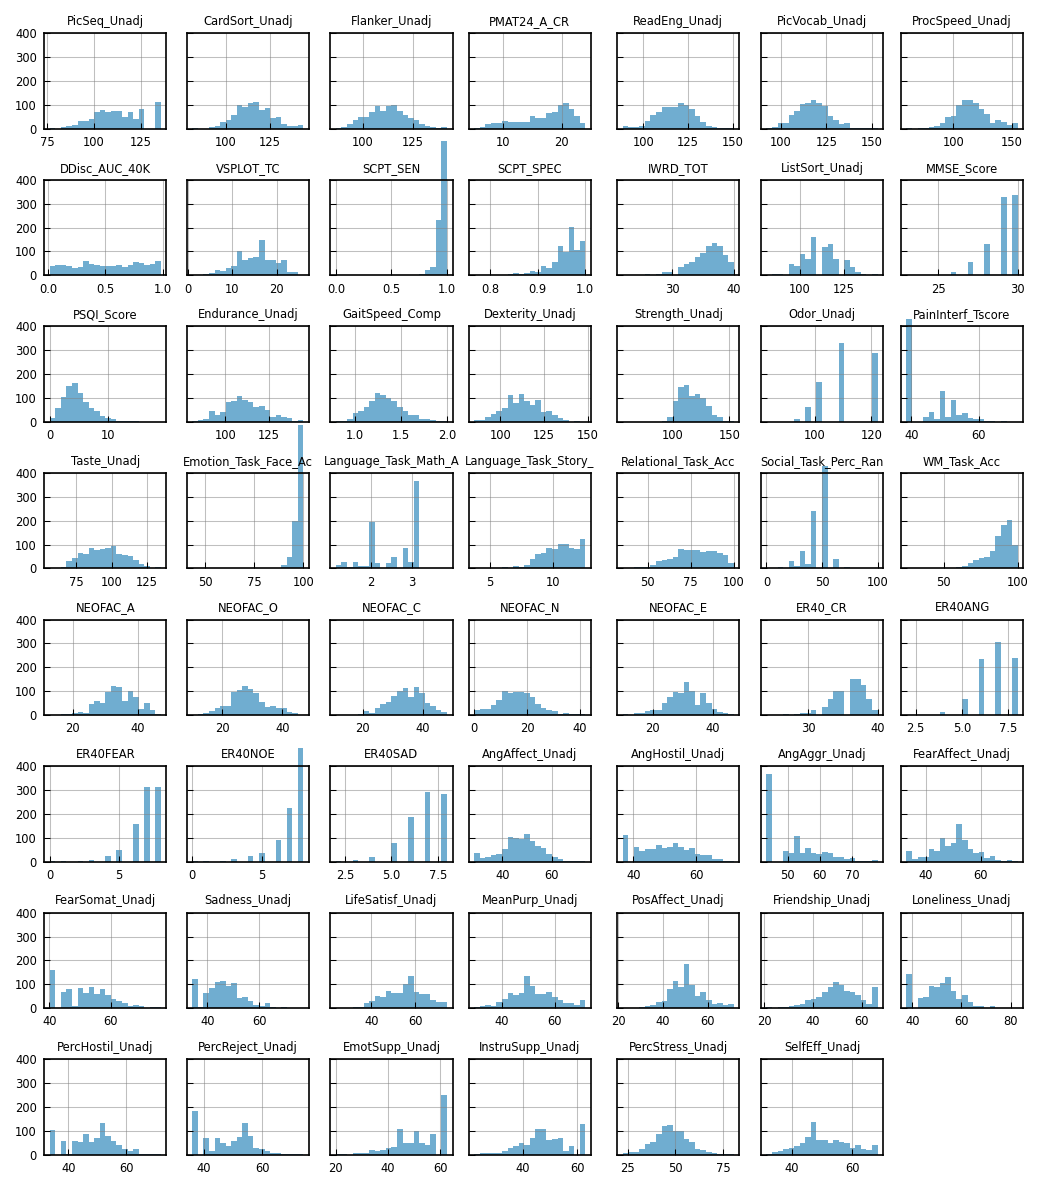

In [11]:
f = plot_behav_histograms(hcp_behav)
f.savefig(hcp_behav_dir / f"hcp_1200_behav_histograms.{FORMAT}", bbox_inches="tight")

Preprocess behavioral targets

- Regress nuisance covariates gender, age, mean FD
- Clip boxplot outliers
- Standard scale

> Nb, here we preprocess all targets, though during behavioral prediction we are more careful to avoid leaking information from the test data.

In [12]:
target_transform = arfcexp.transforms.HCPBehavTargetTransform()

hcp_behav_scale_clean = target_transform.fit_transform(
    pd.concat([covariates, hcp_behav], axis=1)
)

hcp_behav_scale_clean = pd.DataFrame(
    hcp_behav_scale_clean,
    index=hcp_behav.index,
    columns=hcp_behav.columns,
)

hcp_behav_scale_clean.iloc[:5, :5]

,PicSeq_Unadj,CardSort_Unadj,Flanker_Unadj,PMAT24_A_CR,ReadEng_Unadj
Subject,,,,,
181131,0.548870,0.511032,0.142511,-2.021477,-2.529880
245333,1.590545,-0.169074,-0.197214,0.801893,0.367290
106824,1.709131,-0.538988,-0.523129,0.630192,-0.056233
187547,-0.176257,0.633266,1.421572,-2.285705,0.268769
211821,-0.308736,-0.126827,0.242788,0.536193,-0.716461


Note that after preprocessing, all target measures are in the range `[-3, 3]` and the distributions are flattened out. This is good.

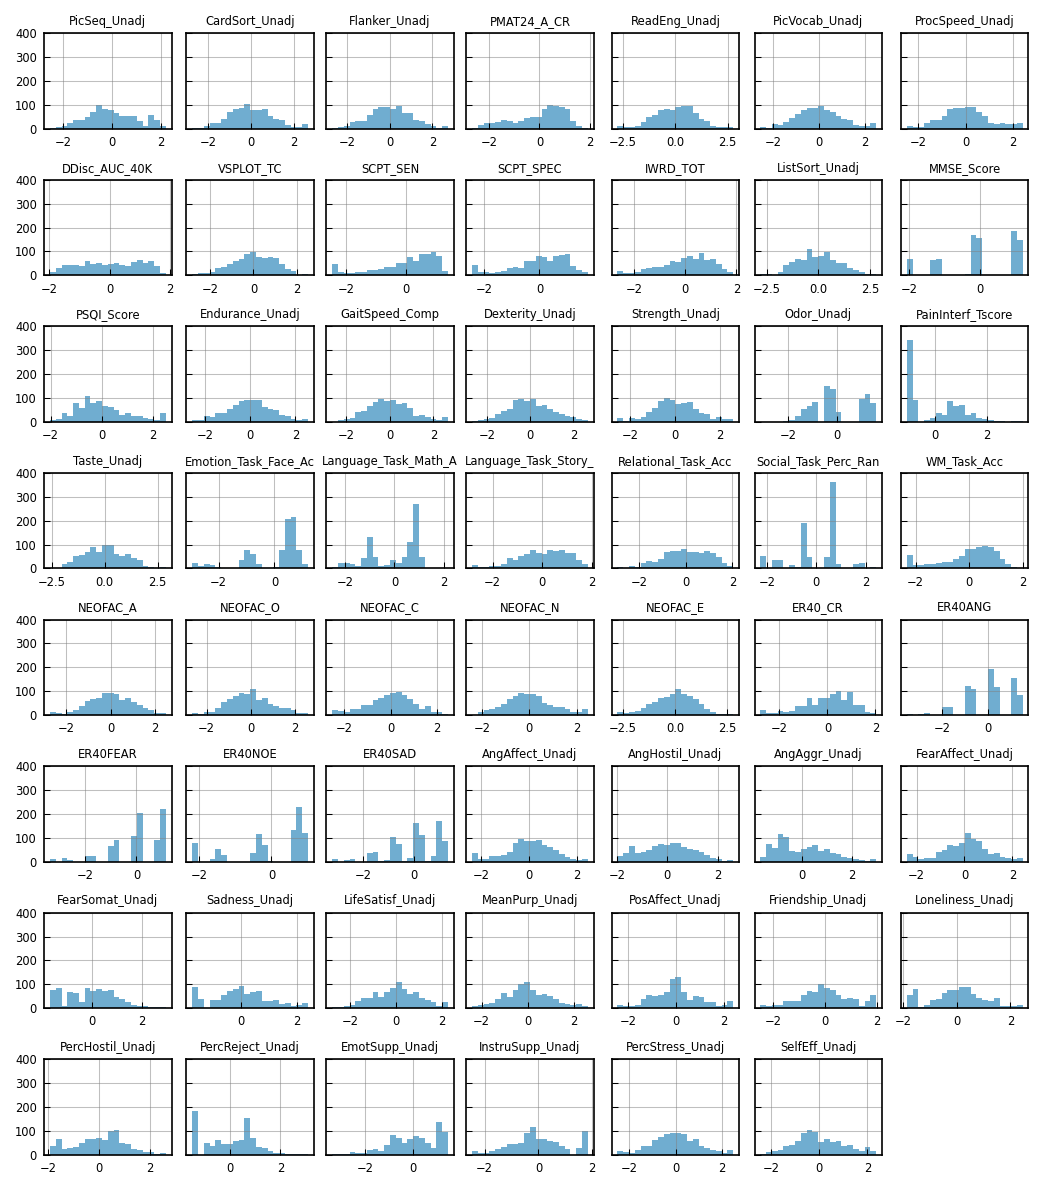

In [13]:
f = plot_behav_histograms(hcp_behav_scale_clean)
f.savefig(
    hcp_behav_dir / f"hcp_1200_behav_scale_clean_histograms.{FORMAT}",
    bbox_inches="tight",
)

### Factor analysis

Find the principal factors explaining the behavioral variation, following (Ooi et al., 2022) and (Kong et al., 2023).

In [14]:
embed = FactorAnalysis(n_components=4, rotation="varimax", random_state=6802)
embed.fit(hcp_behav_scale_clean)

FactorAnalysis(n_components=4, random_state=6802, rotation='varimax')

In [15]:
# flip sign so that most of the large scores are positive
component_sign = np.sign(embed.components_.sum(axis=-1))

# sort components by magnitude
component_order = np.argsort(-np.linalg.norm(embed.components_, axis=1))
component_sign = component_sign[component_order]

components = embed.components_.copy()
components = components[component_order] * component_sign[:, None]

print("Component order:", component_order)
print("Component sign:", component_sign)

Component order: [1 2 3 0]
Component sign: [ 1. -1. -1. -1.]


In [16]:
np.save(hcp_behav_dir / "hcp_1200_behav_factors.npy", components)

Formatted table of top-k measures for each component

In [17]:
topk = 10

factor_topk_tables = []
factor_labels = ["Dissatisfaction", "Cognition", "Support", "Emotion"]

for ii, comp in enumerate(components):
    topkind = np.argsort(-np.abs(comp))[:10]
    records = []
    for jj, idx in enumerate(topkind):
        col = hcp_behav.columns[idx]
        meas = hcp_column_name_map[col]
        val = comp[idx]
        records.append({"measure": meas, "key": col, "score": val})
    factor_topk_tables.append(pd.DataFrame.from_records(records))

factor_topk_table = pd.concat(factor_topk_tables, axis=1)
factor_topk_table.columns = pd.MultiIndex.from_tuples(
    [
        (f"Component {ii + 1}: {factor_labels[ii]}", col)
        for ii in range(len(components))
        for col in ["Measure", "Key", "Score"]
    ],
)

In [18]:
factor_topk_table_style = (
    factor_topk_table.iloc[
        :, [3 * ii + jj for ii in range(4) for jj in [0, 2]]
    ]  # drop key
    .style.format(precision=3)
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)
factor_topk_table_style

In [19]:
factor_topk_table_style.to_html(hcp_behav_dir / "hcp_1200_behav_factors_topk.html")

Get top 5 measures per factor. During behavioral prediction, will use a simple average of these top measures as the target associated to the factor.

Note that previous papers have instead used the factor latent variables themselves as the targets. But this creates an issue of possible data leakage, and is difficult to replicate across studies.

In [20]:
column_idx_map = {col: ii for ii, col in enumerate(hcp_behav.columns)}

factor_topk_weights = {}
for ii, label in enumerate(factor_labels):
    topk_keys = factor_topk_table.iloc[:5, 3 * ii + 1].tolist()

    # uniform average weight vector, but possibly with sign flip
    topk_indices = [column_idx_map[k] for k in topk_keys]
    topk_sign = np.sign(factor_topk_table.iloc[:5, 3 * ii + 2].values)

    topk_weight = np.zeros(len(hcp_behav.columns))
    topk_weight[topk_indices] = topk_sign
    topk_weight /= np.sum(np.abs(topk_weight))

    factor_topk_weights[label] = topk_weight.tolist()

In [21]:
# double check that weights are correct
for label, weight in factor_topk_weights.items():
    print(label)
    weight = np.array(weight)
    (indices,) = weight.nonzero()
    for idx in indices:
        prefix = "-" if weight[idx] < 0 else ""
        print(f"\t{prefix}{hcp_behav.columns[idx]}")

Dissatisfaction
	NEOFAC_N
	AngAffect_Unadj
	FearAffect_Unadj
	Sadness_Unadj
	PercStress_Unadj
Cognition
	PMAT24_A_CR
	ReadEng_Unadj
	PicVocab_Unadj
	Relational_Task_Acc
	WM_Task_Acc
Support
	NEOFAC_E
	MeanPurp_Unadj
	Friendship_Unadj
	-Loneliness_Unadj
	EmotSupp_Unadj
Emotion
	ER40_CR
	ER40ANG
	ER40FEAR
	ER40NOE
	ER40SAD


In [22]:
# save as json
# Nb, print instead of json dump to add extra newline (and avoid ruff fmt)
factor_topk_path = (
    project_root / "resources/column_lists/hcp_1200_behav_factors_topk.json"
)

with factor_topk_path.open("w") as f:
    print(json.dumps(factor_topk_weights), file=f)

Plot of Component scores

- Measures are sorted first by which component they score on most, then by their absolute score on that component.
- Measure values are sign flipped so that the largest component score is positive. Measures with a sign flip have a negative sign prepended on the xtick label.

In [23]:
# sort measures first by which component they contribute to most, then by their
# contribution to that component.


def argsort_components(components: np.ndarray):
    top_component_idx = np.argmax(np.abs(components), axis=0)
    indices = []
    for ii, comp in enumerate(components):
        (indices_i,) = (top_component_idx == ii).nonzero()
        order = np.argsort(-np.abs(comp[indices_i]))
        indices.append(indices_i[order])
    indices = np.concatenate(indices)
    return indices

In [24]:
component_order_indices = argsort_components(components)

In [25]:
# Flip sign of each measures based on the sign of its main component score
top_component_idx = np.argmax(np.abs(components), axis=0)
top_component = components[top_component_idx, np.arange(components.shape[1])]
feature_sign = np.sign(top_component)

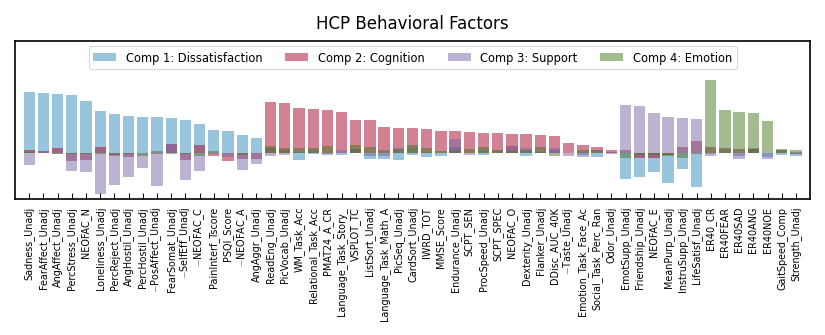

In [26]:
f, ax = plt.subplots(1, 1, figsize=(2 * PLOTW, 0.4 * PLOTW))

flip_components = components * feature_sign
bar_x = np.arange(components.shape[1])

for ii, comp in enumerate(flip_components):
    plt.bar(
        bar_x,
        comp[component_order_indices],
        alpha=0.5,
        label=f"Comp {ii + 1}: {factor_labels[ii]}",
    )

xticklabels = []
for idx in component_order_indices:
    label = hcp_behav.columns[idx][:20]
    if feature_sign[idx] < 0:
        label = f"$-${label}"
    xticklabels.append(label)

plt.xlim(-1, len(comp))
plt.ylim(-0.6, 1.5)

plt.xticks(np.arange(len(xticklabels)), xticklabels, rotation=90, fontsize="xx-small")
plt.yticks([])

plt.legend(loc="upper center", ncol=len(components), fontsize="x-small")
plt.title("HCP Behavioral Factors", fontsize="medium")

plt.grid(False)

plt.savefig(
    hcp_behav_dir / f"hcp_1200_behav_factors_sorted.{FORMAT}", bbox_inches="tight"
)

In [27]:
np.save(hcp_behav_dir / "hcp_1200_behav_factor_order.npy", component_order_indices)